In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv


In [3]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv")

print(df.shape)
print(df.info())
print(df.describe())
print(df.isnull().sum())


(2640, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB
None
              Year        Month  Estimated_Deliveries  Production_Units  \
count  2640.000000  2640

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.drop_duplicates(inplace=True)

df.fillna(df.median(numeric_only=True), inplace=True)

In [6]:
yearly_deliveries = df.groupby('Year')['Estimated_Deliveries'].sum()

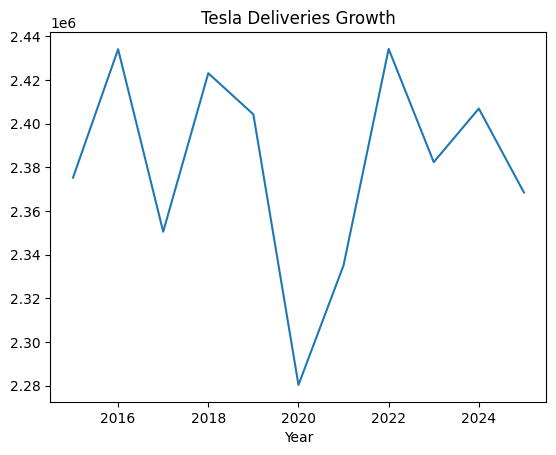

In [7]:
import matplotlib.pyplot as plt

yearly_deliveries.plot(kind='line')
plt.title("Tesla Deliveries Growth")
plt.show()

In [8]:
yearly_prod = df.groupby('Year')['Production_Units'].sum()

<Axes: xlabel='Year'>

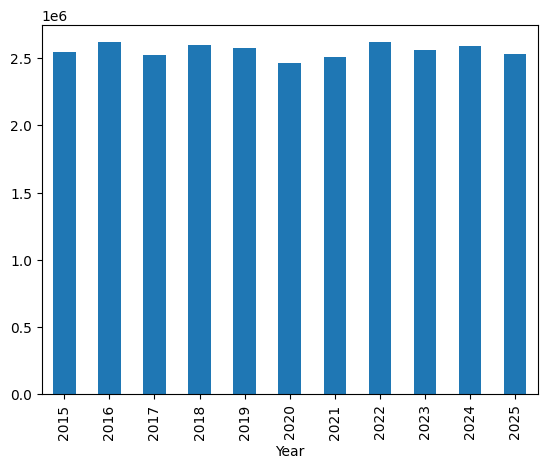

In [9]:
yearly_prod.plot(kind='bar')

In [10]:
region_sales = df.groupby('Region')['Estimated_Deliveries'].sum()

<Axes: ylabel='Model'>

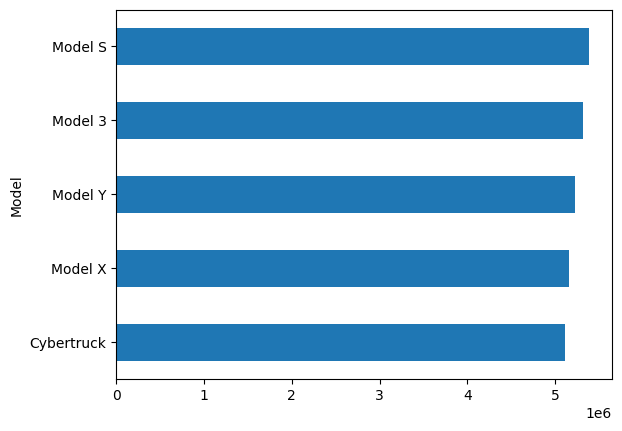

In [11]:
model_sales = df.groupby('Model')['Estimated_Deliveries'].sum()
model_sales.sort_values().plot(kind='barh')

In [12]:
df['Revenue'] = (
    df['Estimated_Deliveries']
    * df['Avg_Price_USD']
)

In [13]:
revenue_yearly = df.groupby('Year')['Revenue'].sum()

In [14]:
co2 = df.groupby('Year')['CO2_Saved_tons'].sum()

<Axes: >

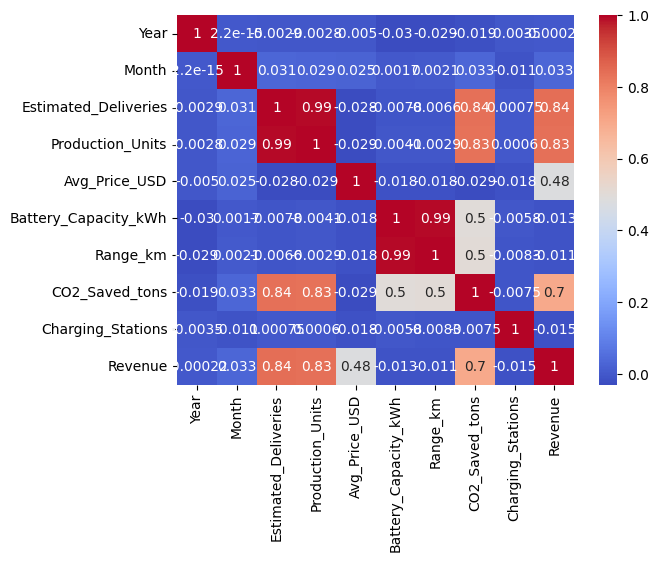

In [15]:
import seaborn as sns

corr = df.corr(numeric_only=True)

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm')

In [16]:
from sklearn.linear_model import LinearRegression

X = df[['Year']]
y = df['Estimated_Deliveries']

model = LinearRegression()
model.fit(X,y)

LinearRegression()

In [17]:
future = pd.DataFrame({
    'Year':[2026,2027,2028]
})

pred = model.predict(future)

In [18]:
print(pred)

[9900.82212121 9897.25920455 9893.69628788]


Business Insights

Based on the exploratory analysis of Tesla deliveries and production data (2015–2025):

Tesla's annual deliveries showed a strong upward trend over the decade, reflecting growing global demand for electric vehicles.
Production units increased consistently alongside deliveries, indicating Tesla's ability to scale manufacturing capacity to meet market demand.
Regions with stronger charging infrastructure generally recorded higher delivery volumes, highlighting the importance of EV ecosystem development.
Higher battery capacity was often associated with greater vehicle range and premium pricing, showing a clear relationship between technical specifications and product positioning.
Tesla's environmental impact increased significantly over time, with cumulative CO₂ savings growing as EV adoption expanded.
Certain Tesla models contributed disproportionately to total deliveries, demonstrating the company's reliance on a few high-performing vehicle segments.
Production and estimated deliveries exhibited a strong positive correlation, suggesting that manufacturing output is one of the key drivers of sales performance.
Conclusion

This project performed a comprehensive analysis of Tesla EA Deliveries and Production Data (2015–2025) to understand delivery trends, production growth, regional performance, and factors influencing Tesla's market expansion.

The workflow included:

Data Loading and Inspection
Data Cleaning and Preprocessing
Exploratory Data Analysis (EDA)
Trend Analysis
Regional and Model-wise Analysis
Revenue Estimation
Correlation Analysis
Environmental Impact Assessment (CO₂ Savings)
Delivery Forecasting

The analysis revealed sustained growth in Tesla's deliveries and production over the years, supported by expanding charging infrastructure and increasing consumer adoption of electric vehicles. Strong relationships were observed between production output, deliveries, battery capacity, and vehicle range.

Overall, the study provides valuable insights into Tesla's operational growth, market performance, and contribution to sustainable transportation while demonstrating how data analytics can be used to uncover business trends and support future forecasting.